# Assignment No. 4 – Denoising Diffusion Probabilistic Model (DDPM)
**Course:** Generative AI (AI4009) | Spring 2026  
**University:** National University of Computer and Emerging Sciences

---
## Table of Contents
1. Environment Setup & Imports  
2. Part 1 – Data Preprocessing  
3. Part 2 – Forward Diffusion Process  
4. Part 3 – U-Net Architecture (Reverse Process)  
5. Part 4 – Training Setup  
6. Part 5 – Image Reconstruction  
7. Part 6 – Image Generation  
8. Visualization Module  
9. Quantitative Evaluation (PSNR & SSIM)  
10. Gradio App Deployment

## 1. Environment Setup & Imports

In [1]:
# Install missing packages (Kaggle has torch/torchvision pre-installed)
!pip install -q gradio scikit-image

In [2]:
import os, math, random, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from torch.cuda.amp import GradScaler, autocast

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Device (supports Kaggle T4×2) ───────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.device_count() > 1:
    print(f"  → {torch.cuda.device_count()} GPUs detected – DataParallel will be used")

Device : cuda
  → 2 GPUs detected – DataParallel will be used


In [3]:
# ════════════════════════════════════════════════════
#  GLOBAL CONFIGURATION  –  Edit here to change run
# ════════════════════════════════════════════════════
class CFG:
    # ── Data ────────────────────────────────────────
    # Change DATA_DIR to match your Kaggle dataset path:
    #   CelebA-HQ : /kaggle/input/celebahq256-images-only/data256x256
    #   FFHQ      : /kaggle/input/ffhq-face-data-set/images1024x1024
    #   WikiArt   : /kaggle/input/wikiart/wikiart
    DATA_DIR = "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs"
    IMG_SIZE     = 128        
    BATCH_SIZE   = 16         
    NUM_WORKERS  = 4

    # ── Diffusion ────────────────────────────────────
    T            = 200        
    BETA_START   = 1e-4
    BETA_END     = 0.02
    SCHEDULE     = "cosine"   # "linear" | "cosine"

    # ── U-Net ────────────────────────────────────────
    BASE_CH      = 64         
    CH_MULT      = (1, 2, 4)
    TIME_EMB_DIM = 256

    # ── Training ─────────────────────────────────────
    EPOCHS       = 20
    LR           = 2e-4
    GRAD_CLIP    = 1.0
    MIXED_PREC   = True       

    # ── I/O ──────────────────────────────────────────
    CKPT_PATH    = "ddpm_best.pt"

cfg = CFG()
print("Config loaded ✓")

Config loaded ✓


## 2. Part 1 – Data Preprocessing

Dataset: 30,000 images found in '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs'
Batches per epoch: 1875


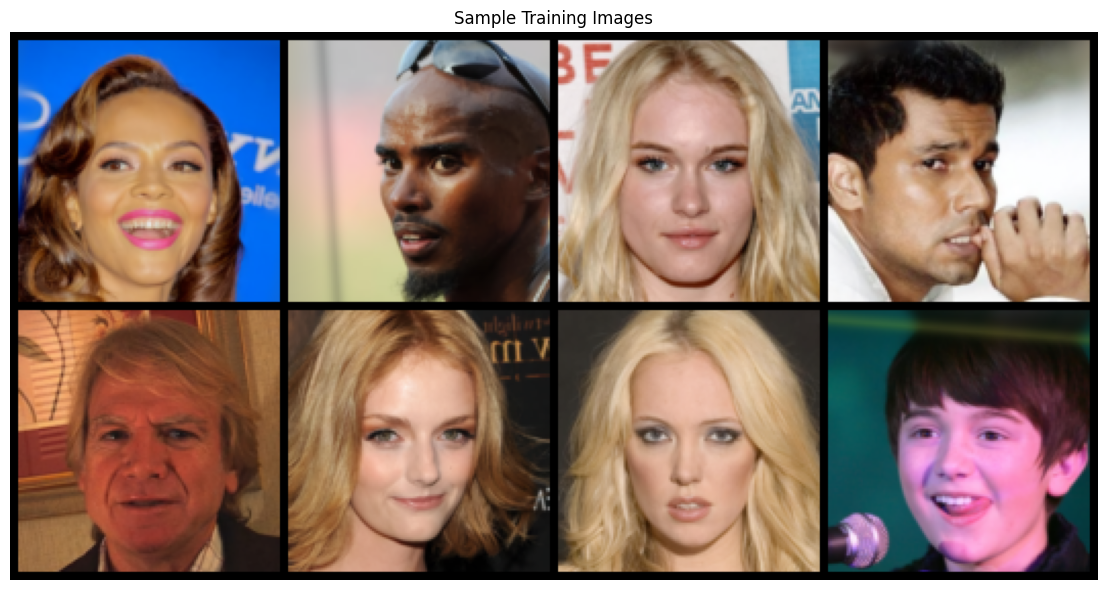

In [4]:
# ── Custom Dataset ──────────────────────────────────────────────
class ImageFolderDataset(Dataset):
    EXTS = {".jpg", ".jpeg", ".png", ".webp"}

    def __init__(self, root, img_size=128, max_samples=None):
        self.paths = []
        for dirpath, _, files in os.walk(root):
            for f in files:
                if os.path.splitext(f)[1].lower() in self.EXTS:
                    self.paths.append(os.path.join(dirpath, f))
        if max_samples:
            self.paths = self.paths[:max_samples]

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
        print(f"Dataset: {len(self.paths):,} images found in '{root}'")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        return self.transform(Image.open(self.paths[idx]).convert("RGB"))


def get_dataloader(data_dir, img_size, batch_size, num_workers):
    ds = ImageFolderDataset(data_dir, img_size)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True,
                    num_workers=num_workers, pin_memory=True, drop_last=True)
    return dl, ds


loader, dataset = get_dataloader(cfg.DATA_DIR, cfg.IMG_SIZE,
                                 cfg.BATCH_SIZE, cfg.NUM_WORKERS)
print(f"Batches per epoch: {len(loader)}")

def denorm(t):
    return (t.clamp(-1, 1) + 1) / 2

sample_batch = next(iter(loader))
grid = make_grid(denorm(sample_batch[:8]), nrow=4, padding=4)
plt.figure(figsize=(12, 6))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Sample Training Images")
plt.tight_layout()
plt.show()

## 3. Part 2 – Forward Diffusion Process

In [5]:
# ── Noise Schedules ─────────────────────────────────────────────
def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_beta_schedule(T, s=0.008):
    """Improved cosine schedule (Nichol & Dhariwal 2021)."""
    steps  = torch.arange(T + 1, dtype=torch.float64)
    alphas = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    alphas = alphas / alphas[0]
    betas  = 1 - (alphas[1:] / alphas[:-1])
    return betas.clamp(0, 0.999).float()


# ── Diffusion Schedule Class ─────────────────────────────────────
class DiffusionSchedule:
    """Pre-computes all DDPM constants and implements q_sample / p_sample."""

    def __init__(self, T=400, schedule="cosine", beta_start=1e-4, beta_end=0.02):
        self.T = T
        betas  = cosine_beta_schedule(T) if schedule=="cosine"                  else linear_beta_schedule(T, beta_start, beta_end)

        alphas               = 1.0 - betas
        alphas_cumprod       = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev  = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.betas                          = betas
        self.alphas_cumprod                 = alphas_cumprod
        self.sqrt_alphas_cumprod            = alphas_cumprod.sqrt()
        self.sqrt_one_minus_alphas_cumprod  = (1 - alphas_cumprod).sqrt()
        self.posterior_variance             = (
            betas * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod)
        )
        self.sqrt_recip_alphas              = (1.0 / alphas).sqrt()

    # ── helpers ──────────────────────────────────────────────────
    def _get(self, vals, t, shape):
        out = vals.to(t.device)[t]
        return out.reshape(t.shape[0], *((1,) * (len(shape) - 1)))

    # ── Forward process ──────────────────────────────────────────
    def q_sample(self, x0, t, noise=None):
        """
        Add noise to x0 at timestep t.
        x_t = sqrt(ā_t) * x0 + sqrt(1 - ā_t) * ε
        """
        if noise is None:
            noise = torch.randn_like(x0)
        sa  = self._get(self.sqrt_alphas_cumprod, t, x0.shape)
        som = self._get(self.sqrt_one_minus_alphas_cumprod, t, x0.shape)
        return sa * x0 + som * noise, noise

    # ── Single reverse step ───────────────────────────────────────
    def p_sample(self, model, x_t, t_scalar):
        """DDPM ancestral sampling: one denoising step."""
        model.eval()
        with torch.no_grad():
            B      = x_t.shape[0]
            t_b    = torch.full((B,), t_scalar, device=x_t.device, dtype=torch.long)
            eps    = model(x_t, t_b)

            betas_t    = self._get(self.betas, t_b, x_t.shape)
            sqrt_om    = self._get(self.sqrt_one_minus_alphas_cumprod, t_b, x_t.shape)
            sqrt_ra    = self._get(self.sqrt_recip_alphas, t_b, x_t.shape)

            mean = sqrt_ra * (x_t - betas_t / sqrt_om * eps)
            if t_scalar == 0:
                return mean
            var = self._get(self.posterior_variance, t_b, x_t.shape)
            return mean + var.sqrt() * torch.randn_like(x_t)

    # ── Full reverse loop ─────────────────────────────────────────
    def p_sample_loop(self, model, shape, device, capture_every=None):
        x      = torch.randn(shape, device=device)
        frames = [x.clone().cpu()]
        for t in tqdm(reversed(range(self.T)), total=self.T, desc="Sampling"):
            x = self.p_sample(model, x, t)
            if capture_every and t % capture_every == 0:
                frames.append(x.clone().cpu())
        return x, frames


schedule = DiffusionSchedule(T=cfg.T, schedule=cfg.SCHEDULE,
                              beta_start=cfg.BETA_START, beta_end=cfg.BETA_END)
print(f"Schedule: T={cfg.T}, type='{cfg.SCHEDULE}'")

Schedule: T=200, type='cosine'


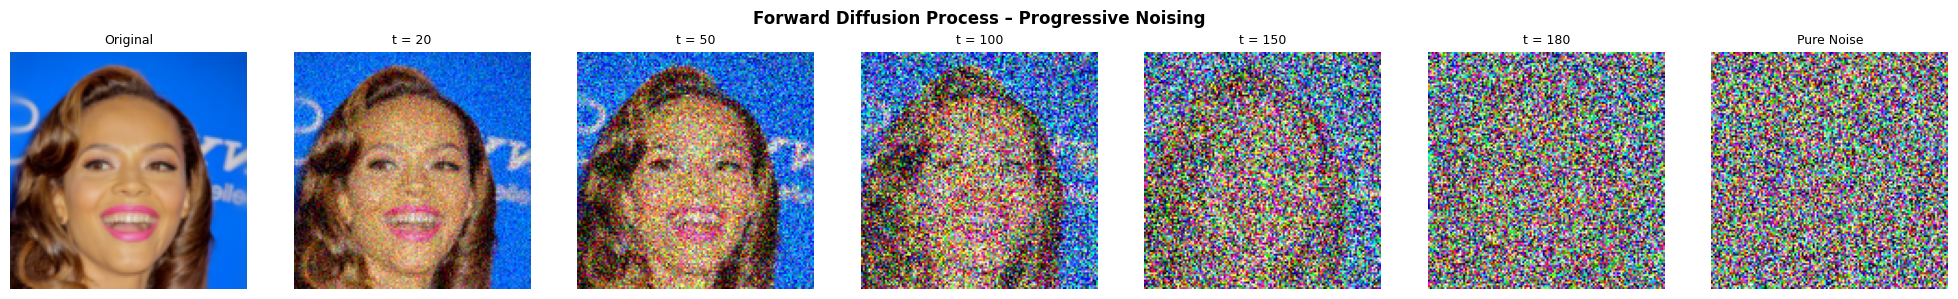

In [6]:
# ── Visualize ≥5 Forward Diffusion Steps ────────────────────────
x0    = sample_batch[:1].to(device)
fracs = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]   # 7 steps shown

fig, axes = plt.subplots(1, len(fracs), figsize=(20, 3))
for ax, frac in zip(axes, fracs):
    if frac == 0:
        img = x0
    elif frac == 1.0:
        t_t = torch.tensor([cfg.T - 1], device=device)
        img, _ = schedule.q_sample(x0, t_t)
    else:
        t_t = torch.tensor([int(frac * cfg.T)], device=device)
        img, _ = schedule.q_sample(x0, t_t)

    label = "Original" if frac == 0 else ("Pure Noise" if frac==1.0 else f"t = {int(frac*cfg.T)}")
    ax.imshow(denorm(img[0].cpu()).permute(1,2,0).clamp(0,1).numpy())
    ax.set_title(label, fontsize=9); ax.axis("off")

plt.suptitle("Forward Diffusion Process – Progressive Noising", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Part 3 – U-Net Architecture (Reverse Process / Denoising Network)

In [7]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device   = t.device
        half_dim = self.dim // 2
        emb      = math.log(10000) / (half_dim - 1)
        emb      = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb      = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, groups=8):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch))
        self.block1   = nn.Sequential(
            nn.GroupNorm(groups, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2   = nn.Sequential(
            nn.GroupNorm(groups, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
    def forward(self, x): return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)


class AttentionBlock(nn.Module):
    def __init__(self, ch, groups=8):
        super().__init__()
        self.norm  = nn.GroupNorm(groups, ch)
        self.qkv   = nn.Conv2d(ch, ch * 3, 1)
        self.out   = nn.Conv2d(ch, ch, 1)
        self.scale = ch ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h    = self.norm(x)
        qkv  = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = torch.softmax((q.transpose(-1, -2) @ k) * self.scale, dim=-1)
        h    = (attn @ v.transpose(-1, -2)).transpose(-1, -2).reshape(B, C, H, W)
        return x + self.out(h)


class UNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=64, ch_mult=(1, 2, 4), time_emb_dim=256):
        super().__init__()
        channels = [base_ch * m for m in ch_mult]  # [64, 128, 256]

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_ch),
            nn.Linear(base_ch, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.init_conv = nn.Conv2d(in_ch, channels[0], 3, padding=1)

        # Encoder
        self.enc_blocks  = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        cur_ch = channels[0]
        for out_ch in channels[1:]:
            self.enc_blocks.append(nn.ModuleList([
                ResBlock(cur_ch, out_ch, time_emb_dim),
                ResBlock(out_ch, out_ch, time_emb_dim),
            ]))
            self.downsamples.append(Downsample(out_ch))
            cur_ch = out_ch

        # Bottleneck
        self.mid1 = ResBlock(channels[-1], channels[-1], time_emb_dim)
        self.attn = AttentionBlock(channels[-1])
        self.mid2 = ResBlock(channels[-1], channels[-1], time_emb_dim)

        # Decoder — skip channels must match encoder output channels
        self.dec_blocks = nn.ModuleList()
        self.upsamples  = nn.ModuleList()
        rev_ch = list(reversed(channels))  # [256, 128, 64]
        for i in range(len(rev_ch) - 1):
            in_c  = rev_ch[i]
            out_c = rev_ch[i + 1]
            skip_c = rev_ch[i]          # skip comes from same level encoder
            self.dec_blocks.append(nn.ModuleList([
                ResBlock(in_c + skip_c, out_c, time_emb_dim),
                ResBlock(out_c, out_c, time_emb_dim),
            ]))
            self.upsamples.append(Upsample(in_c))

        self.final = nn.Sequential(
            nn.GroupNorm(8, channels[0]),
            nn.SiLU(),
            nn.Conv2d(channels[0], in_ch, 1),
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x     = self.init_conv(x)

        # Encoder
        skips = []
        for (r1, r2), ds in zip(self.enc_blocks, self.downsamples):
            x = r1(x, t_emb)
            x = r2(x, t_emb)
            skips.append(x)
            x = ds(x)

        # Bottleneck
        x = self.mid1(x, t_emb)
        x = self.attn(x)
        x = self.mid2(x, t_emb)

        # Decoder
        for (r1, r2), us, skip in zip(self.dec_blocks, self.upsamples, reversed(skips)):
            x    = us(x)
            x    = torch.cat([x, skip], dim=1)
            x    = r1(x, t_emb)
            x    = r2(x, t_emb)

        return self.final(x)


# Instantiate
model = UNet(in_ch=3, base_ch=cfg.BASE_CH, ch_mult=cfg.CH_MULT,
             time_emb_dim=cfg.TIME_EMB_DIM).to(device)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net parameters: {n_params/1e6:.2f}M")

dummy_x = torch.randn(2, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=device)
dummy_t = torch.randint(0, cfg.T, (2,), device=device)
with torch.no_grad():
    out = model(dummy_x, dummy_t)
print(f"Forward-pass OK | {dummy_x.shape} → {out.shape}")

U-Net parameters: 8.62M
Forward-pass OK | torch.Size([2, 3, 128, 128]) → torch.Size([2, 3, 128, 128])


## 5. Part 4 – Training Setup

In [ ]:
# ── MSE Loss (predicted noise vs actual noise) ───────────────────
def diffusion_loss(model, schedule, x0, device):
    B     = x0.shape[0]
    t     = torch.randint(0, schedule.T, (B,), device=device, dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t, _ = schedule.q_sample(x0.to(device), t, noise)
    pred    = model(x_t, t)
    return F.mse_loss(pred, noise)


# ── Optimizer + LR Scheduler ─────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
lr_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
scaler    = GradScaler(enabled=cfg.MIXED_PREC)

# ── Training Loop ────────────────────────────────────────────────
train_losses = []
best_loss    = float("inf")

print(f"Training for {cfg.EPOCHS} epochs  |  Mixed Precision: {cfg.MIXED_PREC}")
print("-" * 60)

for epoch in range(1, cfg.EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for batch in loader:
        x0 = batch.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=cfg.MIXED_PREC):
            loss = diffusion_loss(model, schedule, x0, device)

        scaler.scale(loss).backward()
        if cfg.GRAD_CLIP:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    lr_sched.step()
    avg = epoch_loss / len(loader)
    train_losses.append(avg)

    if avg < best_loss:
        best_loss = avg
        torch.save({"epoch": epoch,
                    "model": model.state_dict(),
                    "optim": optimizer.state_dict(),
                    "loss":  best_loss}, cfg.CKPT_PATH)

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        lr_now  = optimizer.param_groups[0]["lr"]
        print(f"[{epoch:3d}/{cfg.EPOCHS}] loss={avg:.5f} | best={best_loss:.5f} "
              f"| lr={lr_now:.2e} | {elapsed:.1f}s/epoch")

print("\nTraining complete ✓  Best loss:", best_loss)

Training for 20 epochs  |  Mixed Precision: True
------------------------------------------------------------


/tmp/ipykernel_55/853764053.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=cfg.MIXED_PREC)
/tmp/ipykernel_55/853764053.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.MIXED_PREC):


[  1/20] loss=0.03965 | best=0.03965 | lr=1.99e-04 | 441.0s/epoch
[  5/20] loss=0.02311 | best=0.02311 | lr=1.71e-04 | 468.8s/epoch
[ 10/20] loss=0.02181 | best=0.02166 | lr=1.00e-04 | 468.8s/epoch
[ 15/20] loss=0.02105 | best=0.02072 | lr=2.93e-05 | 454.5s/epoch


In [ ]:
# ── Training Loss Plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color="steelblue", linewidth=2, label="Train Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Training Loss vs Epochs – Evidence of Stable Training")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Final loss : {train_losses[-1]:.5f}")
print(f"Best  loss : {best_loss:.5f}")

## 6. Part 5 – Image Reconstruction (Core Task)

In [ ]:
# ── Load best checkpoint ─────────────────────────────────────────
ckpt = torch.load(cfg.CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Checkpoint loaded – epoch {ckpt['epoch']} | loss {ckpt['loss']:.5f}")

# ── Select a target image ─────────────────────────────────────────
target      = dataset[0].unsqueeze(0).to(device)   # first dataset image
noise_start = torch.randn_like(target)             # pure noise

# ── Run reverse diffusion ─────────────────────────────────────────
capture_at  = set(range(0, cfg.T, max(1, cfg.T // 6)))   # ~6 frames
recon_steps = [noise_start.clone().cpu()]
x           = noise_start.clone()

model.eval()
with torch.no_grad():
    for t_val in tqdm(reversed(range(cfg.T)), total=cfg.T, desc="Reconstructing"):
        x = schedule.p_sample(model, x, t_val)
        if t_val in capture_at:
            recon_steps.append(x.clone().cpu())

reconstructed = x.cpu()

# ── Side-by-side comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [target.cpu(), noise_start.cpu(), reconstructed],
    ["Target Image", "Starting Noise", "Reconstructed"]
):
    ax.imshow(denorm(img[0]).permute(1,2,0).clamp(0,1).numpy())
    ax.set_title(title, fontsize=12, fontweight="bold"); ax.axis("off")

plt.suptitle("Part 5 – Reconstruction: Target vs Generated", fontsize=13)
plt.tight_layout(); plt.show()

## 7. Part 6 – Image Generation from Pure Noise

In [ ]:
# ── Generate 5 new images ─────────────────────────────────────────
NUM_GEN = 5
gen_imgs = []

model.eval()
for i in range(NUM_GEN):
    x = torch.randn(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=device)
    with torch.no_grad():
        for t_val in tqdm(reversed(range(cfg.T)), total=cfg.T,
                          desc=f"Image {i+1}/{NUM_GEN}", leave=False):
            x = schedule.p_sample(model, x, t_val)
    gen_imgs.append(x.cpu())

gen_imgs = torch.cat(gen_imgs, dim=0)

# ── Display ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_GEN, figsize=(18, 4))
for ax, img in zip(axes, gen_imgs):
    ax.imshow(denorm(img).permute(1,2,0).clamp(0,1).numpy())
    ax.axis("off")
plt.suptitle("Part 6 – 5 Generated Images from Pure Noise",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 8. Visualization Module

In [ ]:
# ════════════════════════════════════════════════════════════════
#  COMPLETE VISUALIZATION UTILITY
# ════════════════════════════════════════════════════════════════

def viz_forward(x0, schedule, T, n=7, title="Forward Diffusion Steps"):
    """Show n noising steps."""
    fracs = np.linspace(0, 1, n)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    for ax, frac in zip(axes, fracs):
        if frac == 0:
            img = x0
        else:
            t_v = min(int(frac * T), T - 1)
            t_t = torch.tensor([t_v], device=x0.device)
            img, _ = schedule.q_sample(x0, t_t)
        label = "Original" if frac==0 else ("Pure Noise" if frac==1.0 else f"t={int(frac*T)}")
        ax.imshow(denorm(img[0].cpu()).permute(1,2,0).clamp(0,1).numpy())
        ax.set_title(label, fontsize=9); ax.axis("off")
    plt.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()


def viz_reverse(steps, title="Reverse Diffusion (Denoising) Steps"):
    """Show intermediate denoising frames."""
    n = len(steps)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    for i, (ax, img) in enumerate(zip(axes, steps)):
        ax.imshow(denorm(img[0]).permute(1,2,0).clamp(0,1).numpy())
        ax.set_title(f"Step {i+1}", fontsize=9); ax.axis("off")
    plt.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()


def viz_generated(images, title="Generated Images"):
    """Show a grid of generated images."""
    grid = make_grid(denorm(images), nrow=min(5, len(images)), padding=4)
    plt.figure(figsize=(16, 4))
    plt.imshow(grid.permute(1,2,0).clamp(0,1).numpy())
    plt.axis("off"); plt.title(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()


# ── Run all three visualizations ─────────────────────────────────
viz_forward(dataset[2].unsqueeze(0).to(device), schedule, cfg.T,
            n=7, title="≥5 Forward Diffusion Steps (Noising)")

viz_reverse(recon_steps, title="≥5 Reverse Diffusion Steps (Denoising)")

viz_generated(gen_imgs, title="5 Final Generated Images")

## 9. Quantitative Evaluation – PSNR & SSIM

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity  as ssim_fn

def t2np(tensor):
    """[-1,1] (C,H,W) tensor → uint8 (H,W,C) numpy."""
    arr = denorm(tensor).permute(1,2,0).clamp(0,1).numpy()
    return (arr * 255).astype(np.uint8)

def metrics(tgt, gen):
    t, g = t2np(tgt), t2np(gen)
    p    = psnr_fn(t, g, data_range=255)
    s    = ssim_fn(t, g, channel_axis=2, data_range=255)
    return p, s

# ── Reconstruction metrics ────────────────────────────────────────
p_r, s_r = metrics(target[0].cpu(), reconstructed[0])
print("=" * 45)
print("  Quantitative Evaluation – Reconstruction")
print("=" * 45)
print(f"  PSNR  : {p_r:.2f} dB")
print(f"  SSIM  : {s_r:.4f}  (1.0 = perfect)")
print("=" * 45)

# ── Per-image generation metrics ─────────────────────────────────
print("\nGenerated images vs first dataset sample:")
ref = dataset[0]
for i, g in enumerate(gen_imgs):
    p_i, s_i = metrics(ref, g)
    print(f"  Image {i+1}: PSNR = {p_i:.2f} dB | SSIM = {s_i:.4f}")

## 10. Gradio App Deployment

In [ ]:
import gradio as gr

# ── Backend ───────────────────────────────────────────────────────
def generate(num_images: int, seed: int, show_steps: bool):
    torch.manual_seed(int(seed))
    model.eval()
    result_pil, step_pil = [], []

    for i in range(int(num_images)):
        x     = torch.randn(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=device)
        steps = []
        cap   = set(range(0, cfg.T, max(1, cfg.T // 8)))
        with torch.no_grad():
            for t_val in reversed(range(cfg.T)):
                x = schedule.p_sample(model, x, t_val)
                if show_steps and t_val in cap:
                    steps.append(x.clone().cpu())
        # Final image
        arr = (denorm(x[0].cpu()).permute(1,2,0).clamp(0,1).numpy() * 255).astype(np.uint8)
        result_pil.append(Image.fromarray(arr))
        # Intermediate steps (first image only)
        if i == 0 and show_steps:
            for s in steps:
                a = (denorm(s[0]).permute(1,2,0).clamp(0,1).numpy() * 255).astype(np.uint8)
                step_pil.append(Image.fromarray(a))

    return result_pil, step_pil if step_pil else [result_pil[0]]


# ── Gradio UI ──────────────────────────────────────────────────────
with gr.Blocks(title="DDPM Generator", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        "# 🎨 DDPM – Diffusion Image Generator\n"
        "Generates high-quality images from **pure random noise** using a from-scratch DDPM."
    )
    with gr.Row():
        with gr.Column(scale=1):
            n_slider    = gr.Slider(1, 5, value=3, step=1,  label="Number of images")
            seed_box    = gr.Number(value=42, precision=0,   label="Random seed")
            steps_check = gr.Checkbox(value=True,            label="Show denoising steps")
            btn         = gr.Button("Generate 🚀", variant="primary")

        with gr.Column(scale=3):
            gallery_out = gr.Gallery(label="Generated Images", columns=5, height="auto")

    with gr.Accordion("Intermediate Denoising Steps", open=True):
        steps_out = gr.Gallery(label="Denoising progression", columns=8, height="auto")

    btn.click(generate,
              inputs=[n_slider, seed_box, steps_check],
              outputs=[gallery_out, steps_out])

demo.launch(share=True, debug=False)   # share=True gives a public link on Kaggle

## Bonus – Additional Notes
- **Faster Sampling (DDIM):** Replace ancestral sampling in `p_sample` with DDIM deterministic steps for 10-50× speedup.  
- **Different Schedules:** Change `CFG.SCHEDULE = "linear"` to compare linear vs cosine noise schedules.  
- **Higher Resolution:** Set `CFG.IMG_SIZE = 256` and `CFG.BATCH_SIZE = 8` for 256×256 images.  
- **Conditioning:** Add a class embedding alongside the timestep embedding for class-conditional generation.
